# Step 31 — MemLabs Model A/B Replication on NIFTY50

Same structure as notebook 24 (TATAMOTORS), swapping in NIFTY50 as the price
series — a broader, less noisy regime signal than any single stock. Data is
already daily (2015-02-02 -> 2025-12-31, matches DS3 stock coverage; Kite MCP
2016-2025 + Yahoo Finance ^NSEI gap-fill for 2015), so no 5-min resample step
is needed here.

Correct feature mapping: `close_log_return = log(close_today / close_yesterday)`,
computed on NIFTY50's own daily close. Uses the Train-only fit + separate
Train-only/Test-only prediction rigor established in notebook 22/24 — not the
author's inflated full-df-predict approach.

This is regime/predictability research (is next-day direction predictable from
past returns?), not an fv2 strategy backtest — `cum_trade_log_return` here is
NOT the same metric as fv2's PnL/ZPnL (no position sizing, SL/TP, charges, or
slippage applied). See `30_iteration_instructions.md` for how this fits into
the broader gating work (steps 25-29).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

plt.style.use('dark_background')

daily = pd.read_parquet('../../../../data/historical/daily/NIFTY50.parquet')
daily['datetime'] = pd.to_datetime(daily['datetime'])
if daily['datetime'].dt.tz is not None:
    daily['datetime'] = daily['datetime'].apply(lambda x: x.replace(tzinfo=None))
daily.set_index('datetime', inplace=True)
daily.rename(columns={'close': 'c'}, inplace=True)
daily = daily[['c']]  # keep only what we need, matches notebook 24's `daily` shape

daily['close_log_return'] = np.log(daily['c'] / daily['c'].shift())
daily['close_log_return_lag_1'] = daily['close_log_return'].shift()

print('Daily rows:', len(daily), ' date range:', daily.index.min().date(), '->', daily.index.max().date())
daily.head()

Daily rows: 2702  date range: 2015-02-02 -> 2025-12-31


,c,close_log_return,close_log_return_lag_1
datetime,,,
2015-02-02,8797.400391,NaN,NaN
2015-02-03,8756.549805,-0.004654,NaN
2015-02-04,8723.700195,-0.003758,-0.004654
2015-02-05,8711.700195,-0.001377,-0.003758
2015-02-06,8661.049805,-0.005831,-0.001377


In [2]:
def train_test_curves(df, features, target, test_split=0.25):
    """Fit on Train only. Predict + build equity curve separately for Train, Test, and combined.
    Returns: model, combined_df (with y_hat/signal/trade_log_return/cum), train_only, test_only"""
    df = df.dropna(subset=features + [target])
    df_train, df_test = train_test_split(df, test_size=test_split, shuffle=False)

    model = LinearRegression()
    model.fit(df_train[features], df_train[target])

    combined = df.copy()
    combined['y_hat'] = model.predict(combined[features])
    combined['signal'] = np.sign(combined['y_hat'])
    combined['trade_log_return'] = combined['close_log_return'] * combined['signal']
    combined['cum_trade_log_return'] = combined['trade_log_return'].cumsum()

    train_only = combined.loc[df_train.index]
    test_only = combined.loc[df_test.index].copy()
    test_only['cum_trade_log_return'] = test_only['trade_log_return'].cumsum()  # reset cumsum to Test window only

    return model, combined, train_only, test_only

## Model A — lag_1 only

coef_ = [-0.02127923]  intercept_ = 0.0003585083825860444

Combined signal value_counts:
signal
 1.0    2612
-1.0      88
Name: count, dtype: int64

Combined final cum: 1.0803036853999526
Train  final cum:   0.6429824529560695  (n= 2025 )
Test   final cum:   0.43732123244388205  (n= 675 )


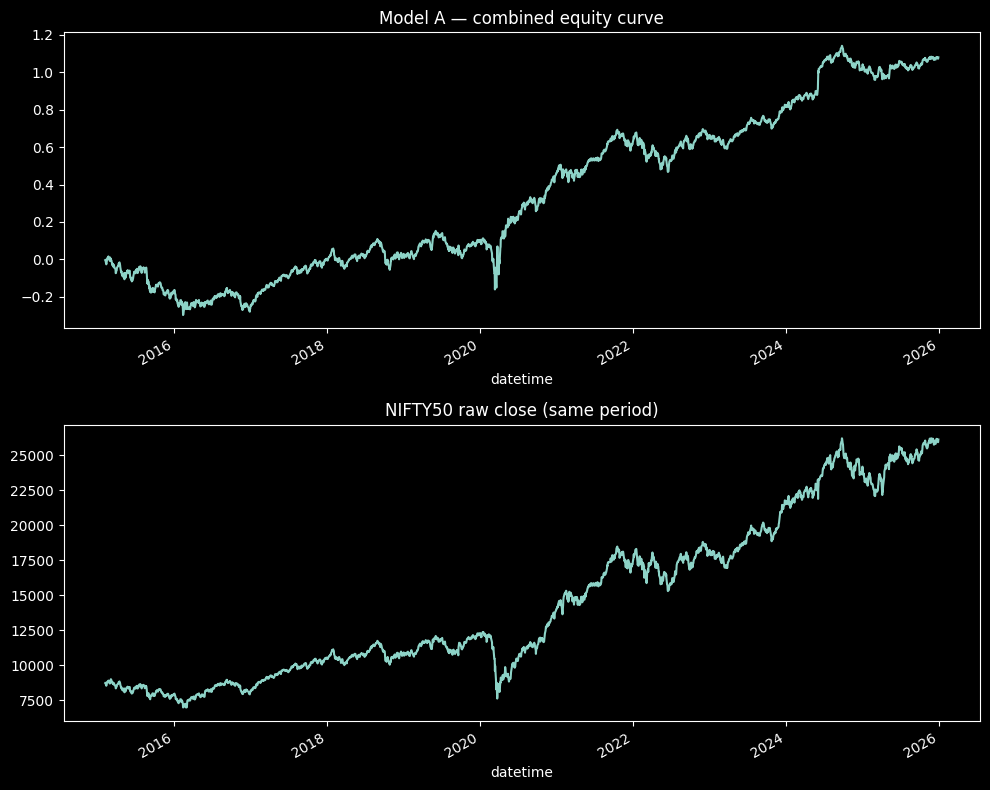

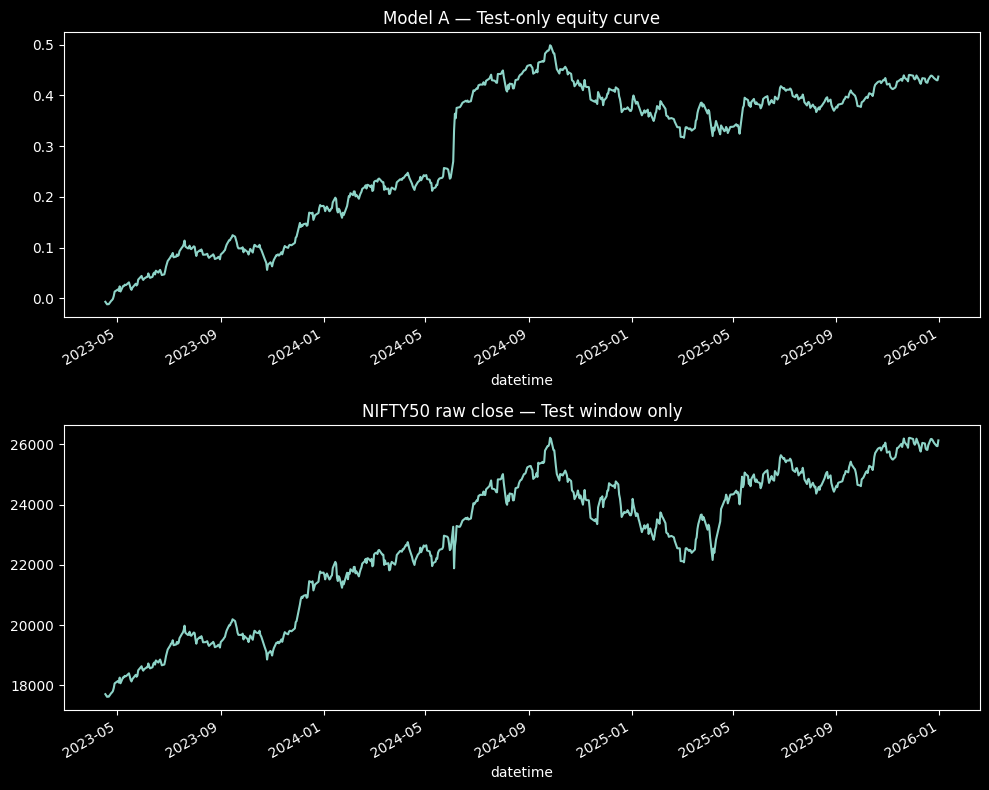

In [3]:
model_a, comb_a, train_a, test_a = train_test_curves(daily, ['close_log_return_lag_1'], 'close_log_return')
print('coef_ =', model_a.coef_, ' intercept_ =', model_a.intercept_)
print()
print('Combined signal value_counts:')
print(comb_a['signal'].value_counts())
print()
print('Combined final cum:', comb_a['cum_trade_log_return'].iloc[-1])
print('Train  final cum:  ', train_a['cum_trade_log_return'].iloc[-1], ' (n=', len(train_a), ')')
print('Test   final cum:  ', test_a['cum_trade_log_return'].iloc[-1], ' (n=', len(test_a), ')')

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
comb_a['cum_trade_log_return'].plot(ax=axes[0], title='Model A — combined equity curve')
comb_a['c'].plot(ax=axes[1], title='NIFTY50 raw close (same period)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
test_a['cum_trade_log_return'].plot(ax=axes[0], title='Model A — Test-only equity curve')
test_a['c'].plot(ax=axes[1], title='NIFTY50 raw close — Test window only')
plt.tight_layout()
plt.show()

Model A Test final cum:    0.43732123244388205
Buy-and-hold Test final cum: 0.3822985162560341
Model A edge over buy-and-hold: 0.05502271618784793


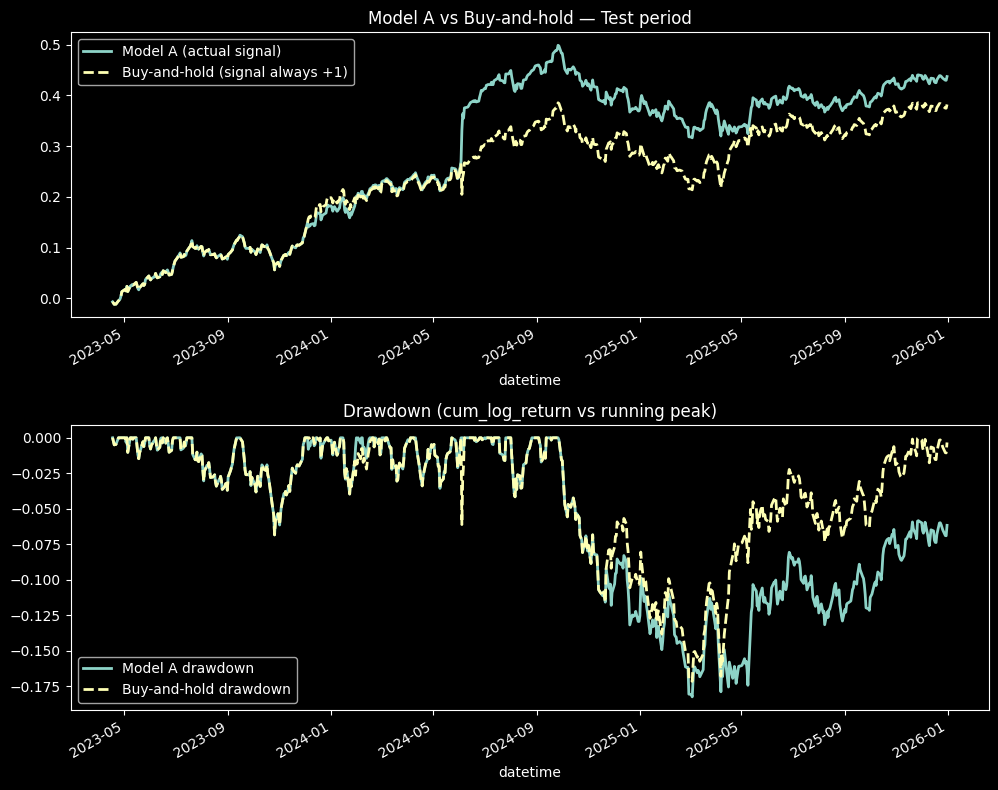

In [4]:
# Buy-and-hold baseline: same cum_trade_log_return math, signal forced to always +1 (never flips to -1)
buy_hold_a = test_a.copy()
buy_hold_a['cum_buy_hold'] = buy_hold_a['close_log_return'].cumsum()

print('Model A Test final cum:   ', test_a['cum_trade_log_return'].iloc[-1])
print('Buy-and-hold Test final cum:', buy_hold_a['cum_buy_hold'].iloc[-1])
print('Model A edge over buy-and-hold:', test_a['cum_trade_log_return'].iloc[-1] - buy_hold_a['cum_buy_hold'].iloc[-1])

dd_model_a = test_a['cum_trade_log_return'] - test_a['cum_trade_log_return'].cummax()
dd_bh_a = buy_hold_a['cum_buy_hold'] - buy_hold_a['cum_buy_hold'].cummax()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
test_a['cum_trade_log_return'].plot(ax=axes[0], label='Model A (actual signal)', linewidth=2)
buy_hold_a['cum_buy_hold'].plot(ax=axes[0], label='Buy-and-hold (signal always +1)', linewidth=2, linestyle='--')
axes[0].set_title('Model A vs Buy-and-hold — Test period')
axes[0].legend()

dd_model_a.plot(ax=axes[1], label='Model A drawdown', linewidth=2)
dd_bh_a.plot(ax=axes[1], label='Buy-and-hold drawdown', linewidth=2, linestyle='--')
axes[1].set_title('Drawdown (cum_log_return vs running peak)')
axes[1].legend()

plt.tight_layout()
plt.show()

## MA-alone — 40-day rolling mean of lag_1

coef_ = [0.06606148]  intercept_ = 0.00034568869556830855

Combined signal value_counts:
signal
 1.0    2631
-1.0      30
Name: count, dtype: int64

Combined final cum: 1.1205959882821457
Train  final cum:   0.7431683586521218  (n= 1995 )
Test   final cum:   0.3774276296300226  (n= 666 )


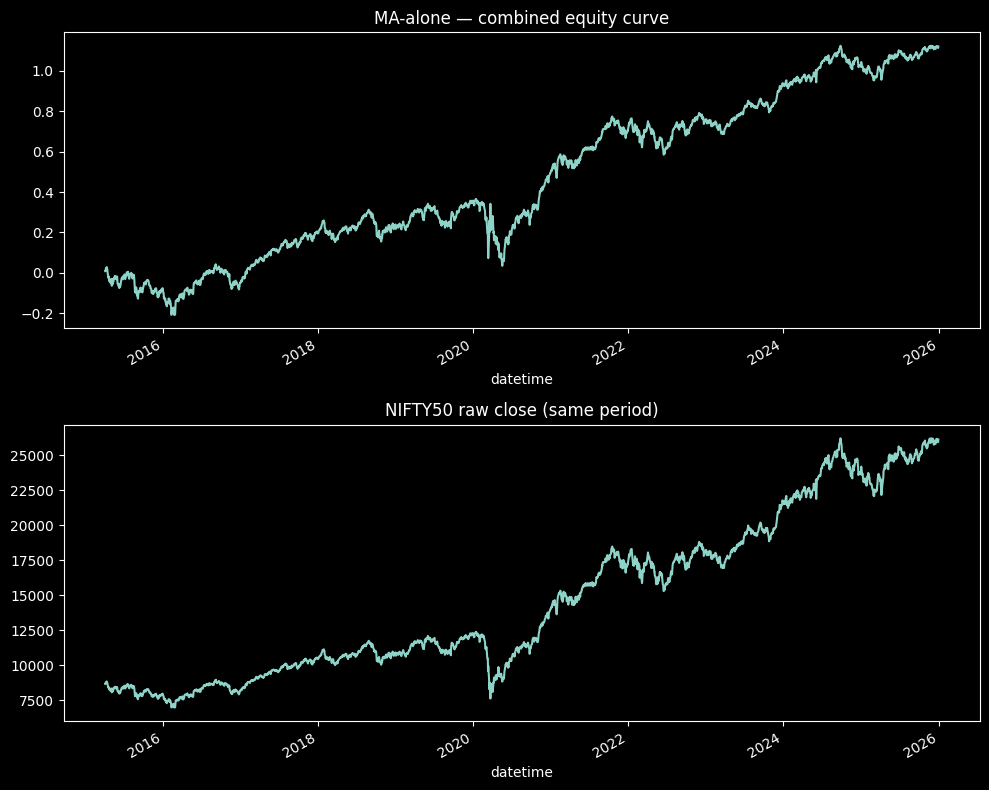

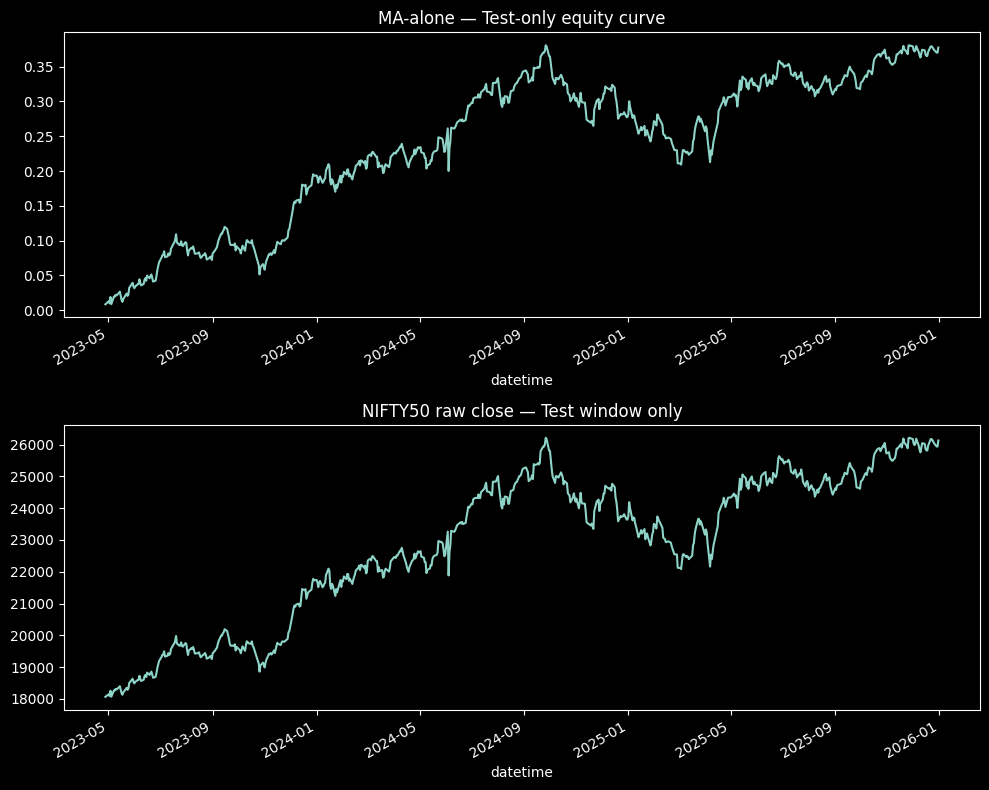

In [5]:
daily['close_log_return_ma_lag_1'] = daily['close_log_return_lag_1'].rolling(40).mean()

model_ma, comb_ma, train_ma, test_ma = train_test_curves(daily, ['close_log_return_ma_lag_1'], 'close_log_return')
print('coef_ =', model_ma.coef_, ' intercept_ =', model_ma.intercept_)
print()
print('Combined signal value_counts:')
print(comb_ma['signal'].value_counts())
print()
print('Combined final cum:', comb_ma['cum_trade_log_return'].iloc[-1])
print('Train  final cum:  ', train_ma['cum_trade_log_return'].iloc[-1], ' (n=', len(train_ma), ')')
print('Test   final cum:  ', test_ma['cum_trade_log_return'].iloc[-1], ' (n=', len(test_ma), ')')

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
comb_ma['cum_trade_log_return'].plot(ax=axes[0], title='MA-alone — combined equity curve')
comb_ma['c'].plot(ax=axes[1], title='NIFTY50 raw close (same period)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
test_ma['cum_trade_log_return'].plot(ax=axes[0], title='MA-alone — Test-only equity curve')
test_ma['c'].plot(ax=axes[1], title='NIFTY50 raw close — Test window only')
plt.tight_layout()
plt.show()

MA-alone Test final cum:    0.3774276296300226
Buy-and-hold Test final cum: 0.3774276296300226
MA-alone edge over buy-and-hold: 0.0


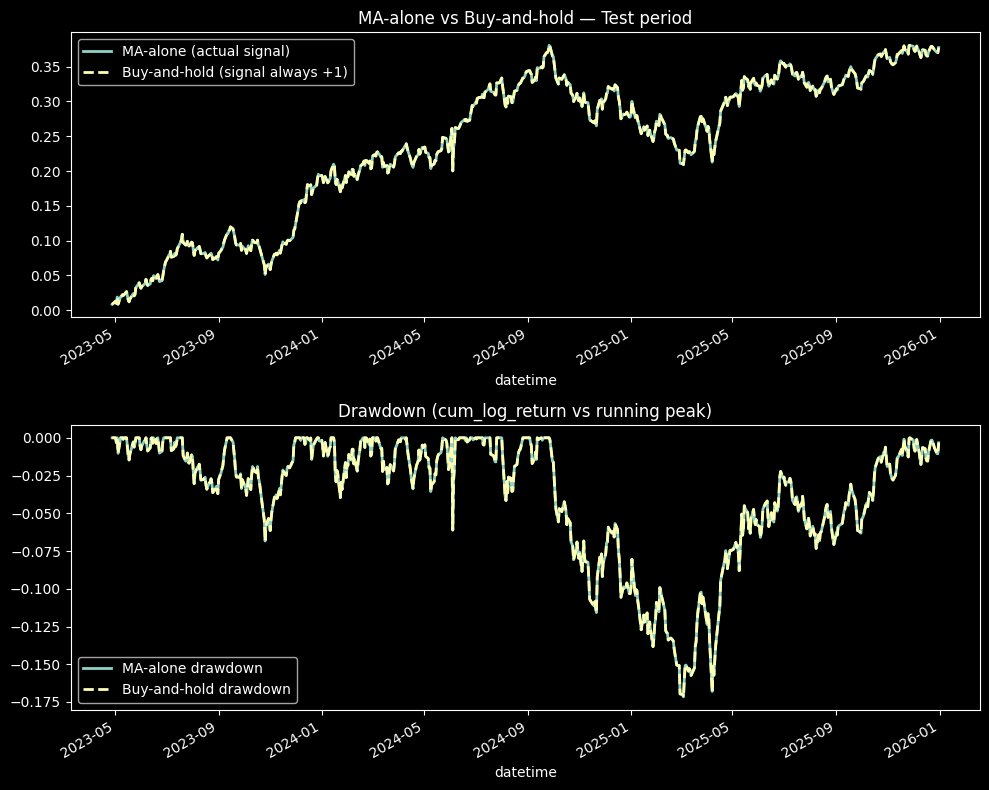

In [6]:
# Buy-and-hold baseline: same cum_trade_log_return math, signal forced to always +1 (never flips to -1)
buy_hold_ma = test_ma.copy()
buy_hold_ma['cum_buy_hold'] = buy_hold_ma['close_log_return'].cumsum()

print('MA-alone Test final cum:   ', test_ma['cum_trade_log_return'].iloc[-1])
print('Buy-and-hold Test final cum:', buy_hold_ma['cum_buy_hold'].iloc[-1])
print('MA-alone edge over buy-and-hold:', test_ma['cum_trade_log_return'].iloc[-1] - buy_hold_ma['cum_buy_hold'].iloc[-1])

dd_model_ma = test_ma['cum_trade_log_return'] - test_ma['cum_trade_log_return'].cummax()
dd_bh_ma = buy_hold_ma['cum_buy_hold'] - buy_hold_ma['cum_buy_hold'].cummax()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
test_ma['cum_trade_log_return'].plot(ax=axes[0], label='MA-alone (actual signal)', linewidth=2)
buy_hold_ma['cum_buy_hold'].plot(ax=axes[0], label='Buy-and-hold (signal always +1)', linewidth=2, linestyle='--')
axes[0].set_title('MA-alone vs Buy-and-hold — Test period')
axes[0].legend()

dd_model_ma.plot(ax=axes[1], label='MA-alone drawdown', linewidth=2)
dd_bh_ma.plot(ax=axes[1], label='Buy-and-hold drawdown', linewidth=2, linestyle='--')
axes[1].set_title('Drawdown (cum_log_return vs running peak)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Model B — lag_1 + ma_lag_1 combined

coef_ = [-0.02547086  0.09047816]  intercept_ = 0.00034665797982796225

Combined signal value_counts:
signal
 1.0    2492
-1.0     169
Name: count, dtype: int64

Combined final cum: 1.3247924527379284
Train  final cum:   0.9452993124615388  (n= 1995 )
Test   final cum:   0.379493140276388  (n= 666 )


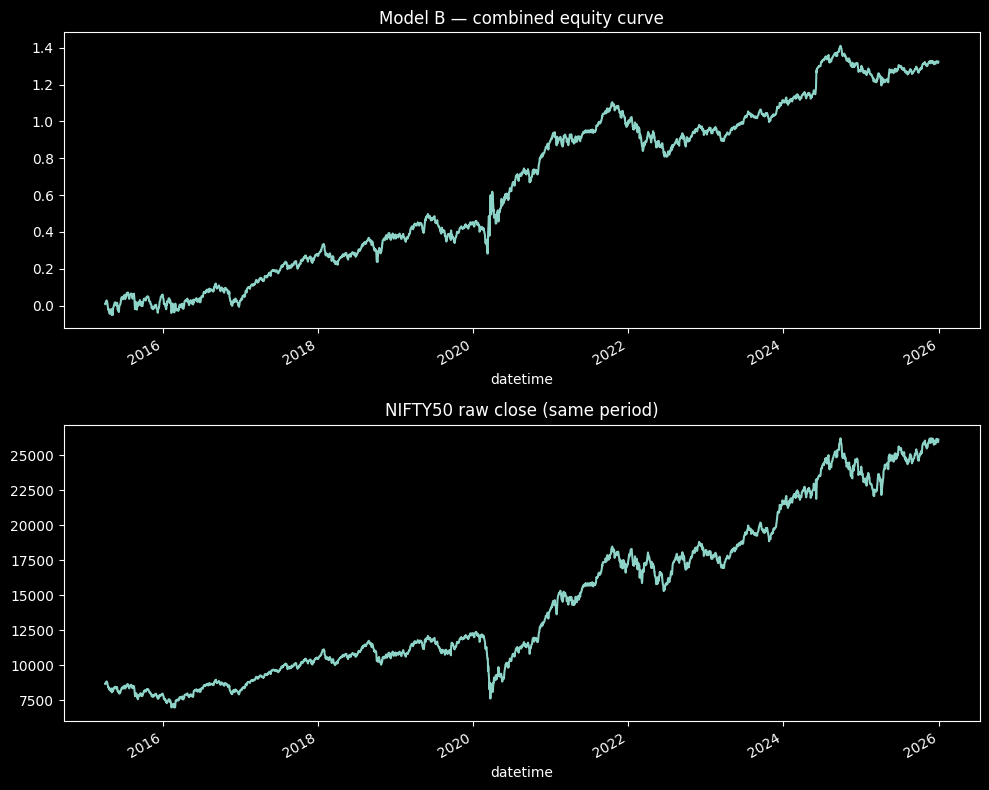

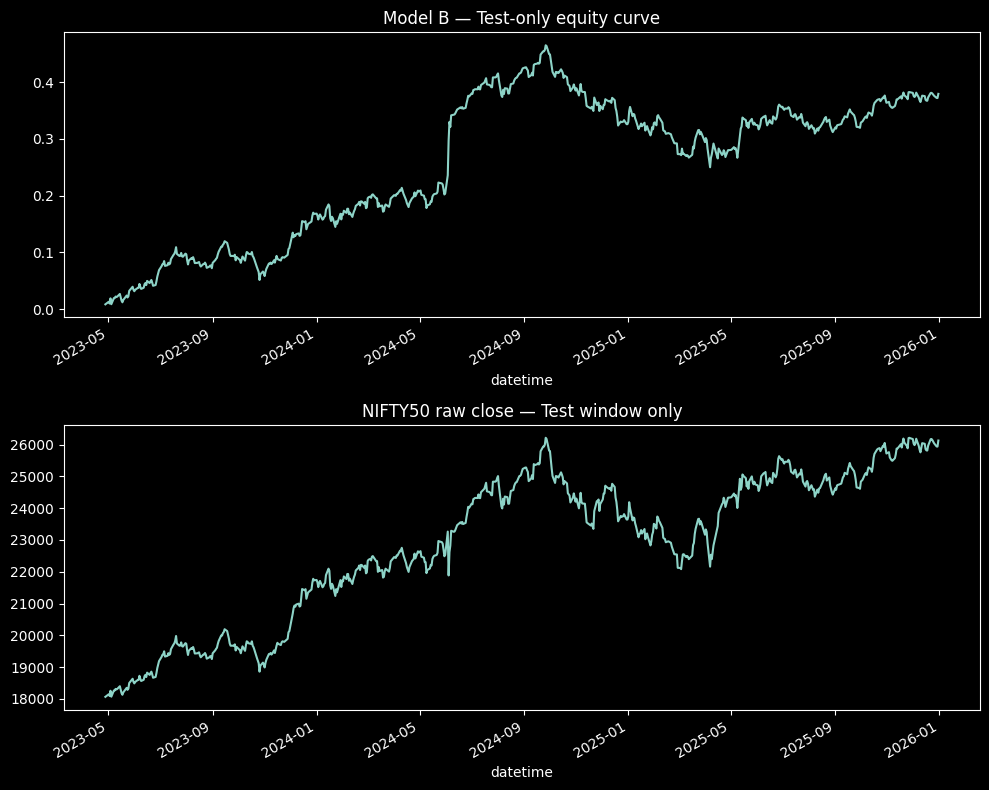

In [7]:
model_b, comb_b, train_b, test_b = train_test_curves(daily, ['close_log_return_lag_1', 'close_log_return_ma_lag_1'], 'close_log_return')
print('coef_ =', model_b.coef_, ' intercept_ =', model_b.intercept_)
print()
print('Combined signal value_counts:')
print(comb_b['signal'].value_counts())
print()
print('Combined final cum:', comb_b['cum_trade_log_return'].iloc[-1])
print('Train  final cum:  ', train_b['cum_trade_log_return'].iloc[-1], ' (n=', len(train_b), ')')
print('Test   final cum:  ', test_b['cum_trade_log_return'].iloc[-1], ' (n=', len(test_b), ')')

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
comb_b['cum_trade_log_return'].plot(ax=axes[0], title='Model B — combined equity curve')
comb_b['c'].plot(ax=axes[1], title='NIFTY50 raw close (same period)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
test_b['cum_trade_log_return'].plot(ax=axes[0], title='Model B — Test-only equity curve')
test_b['c'].plot(ax=axes[1], title='NIFTY50 raw close — Test window only')
plt.tight_layout()
plt.show()

Model B Test final cum:    0.379493140276388
Buy-and-hold Test final cum: 0.3774276296300226
Model B edge over buy-and-hold: 0.0020655106463653983


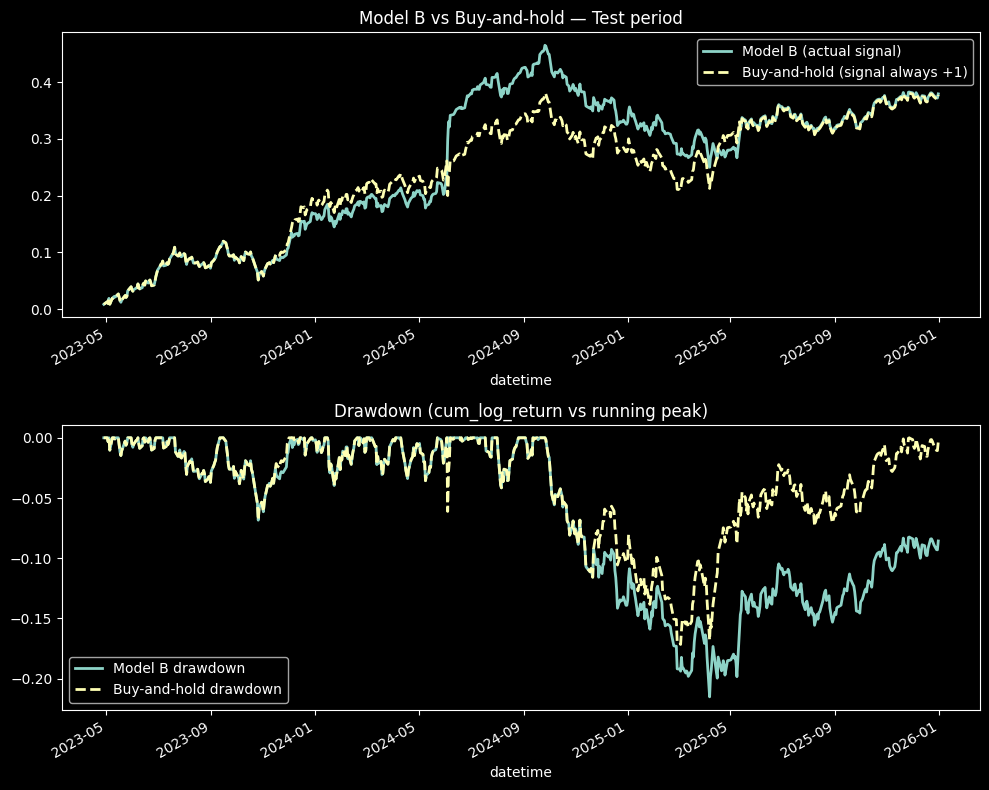

In [8]:
# Buy-and-hold baseline: same cum_trade_log_return math, signal forced to always +1 (never flips to -1)
buy_hold_b = test_b.copy()
buy_hold_b['cum_buy_hold'] = buy_hold_b['close_log_return'].cumsum()

print('Model B Test final cum:   ', test_b['cum_trade_log_return'].iloc[-1])
print('Buy-and-hold Test final cum:', buy_hold_b['cum_buy_hold'].iloc[-1])
print('Model B edge over buy-and-hold:', test_b['cum_trade_log_return'].iloc[-1] - buy_hold_b['cum_buy_hold'].iloc[-1])

dd_model_b = test_b['cum_trade_log_return'] - test_b['cum_trade_log_return'].cummax()
dd_bh_b = buy_hold_b['cum_buy_hold'] - buy_hold_b['cum_buy_hold'].cummax()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
test_b['cum_trade_log_return'].plot(ax=axes[0], label='Model B (actual signal)', linewidth=2)
buy_hold_b['cum_buy_hold'].plot(ax=axes[0], label='Buy-and-hold (signal always +1)', linewidth=2, linestyle='--')
axes[0].set_title('Model B vs Buy-and-hold — Test period')
axes[0].legend()

dd_model_b.plot(ax=axes[1], label='Model B drawdown', linewidth=2)
dd_bh_b.plot(ax=axes[1], label='Buy-and-hold drawdown', linewidth=2, linestyle='--')
axes[1].set_title('Drawdown (cum_log_return vs running peak)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Toy example — how a line actually gets plotted

Before the real Model B boundary: a tiny standalone demo of the mechanic
itself, `y = 2x + 3`, using just 5 x-values. Pick x values -> compute matching
y via the formula -> `ax.plot()` connects consecutive (x, y) pairs with
straight segments. The real boundary plot below does the exact same thing,
just with 100 points instead of 5, and `x2 = -(w1*x1+b)/w2` instead of `y=2x+3`.

x values: [0 1 2 3 4]
y values: [ 3  5  7  9 11]

Coordinate pairs (this is what actually gets plotted):
  (0, 3)
  (1, 5)
  (2, 7)
  (3, 9)
  (4, 11)


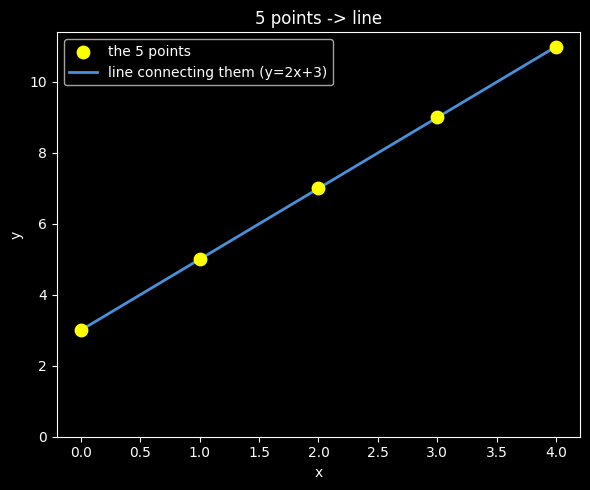

In [9]:
# pick 5 x values
x_toy = np.array([0, 1, 2, 3, 4])
# compute the matching y for each, using y = 2x + 3
y_toy = 2 * x_toy + 3

print('x values:', x_toy)
print('y values:', y_toy)
print()
print('Coordinate pairs (this is what actually gets plotted):')
for xi, yi in zip(x_toy, y_toy):
    print(f'  ({xi}, {yi})')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x_toy, y_toy, color='yellow', s=80, zorder=3, label='the 5 points')
ax.plot(x_toy, y_toy, color='#4a90d9', linewidth=2, label='line connecting them (y=2x+3)')
ax.legend()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('5 points -> line')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## Model B — decision boundary experiment

`y_hat = w1*lag_1 + w2*ma_lag_1 + b`. The boundary where `y_hat = 0` is a line
in (lag_1, ma_lag_1) space, not a single threshold like Model A. Solving for
`ma_lag_1` in terms of `lag_1`: `ma_lag_1 = -(w1*lag_1 + b) / w2`.

Plot every Test-period day as a point (lag_1, ma_lag_1), colored by whether
that day's actual `close_log_return` was up or down, with the boundary line
overlaid — points on the Buy side vs Sell side of the line, and whether the
actual outcome color matches the side, is a direct visual of hit/miss.

w1 (lag_1) = -0.025471   w2 (ma_lag_1) = 0.090478   b = 0.000347


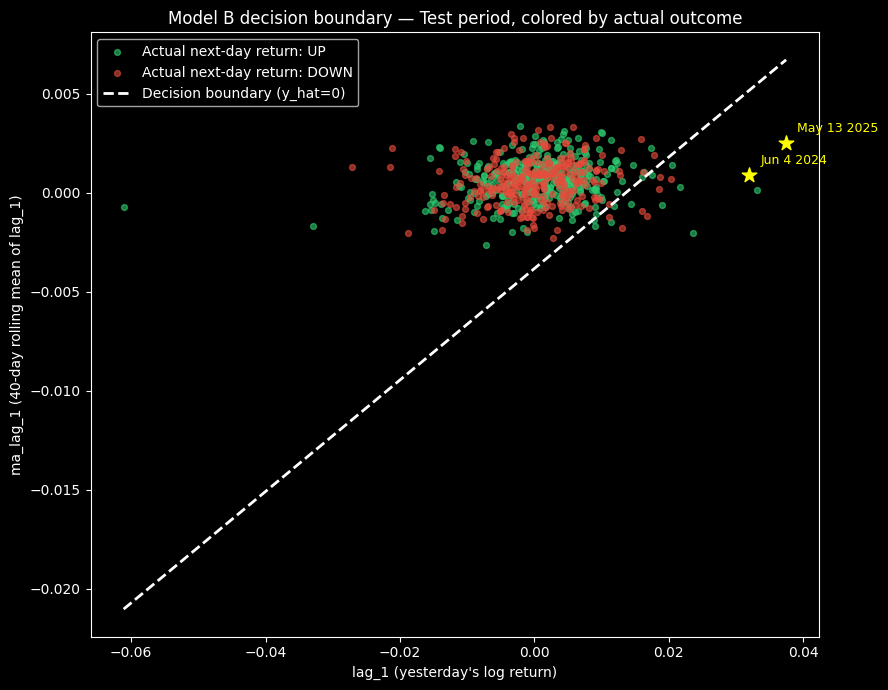

In [10]:
w1, w2 = model_b.coef_
b = model_b.intercept_
print(f'w1 (lag_1) = {w1:.6f}   w2 (ma_lag_1) = {w2:.6f}   b = {b:.6f}')

x1_range = np.linspace(test_b['close_log_return_lag_1'].min(), test_b['close_log_return_lag_1'].max(), 100)
boundary_x2 = -(w1 * x1_range + b) / w2

up_days = test_b[test_b['close_log_return'] > 0]
down_days = test_b[test_b['close_log_return'] <= 0]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(up_days['close_log_return_lag_1'], up_days['close_log_return_ma_lag_1'],
           color='#2ecc71', s=18, alpha=0.6, label='Actual next-day return: UP')
ax.scatter(down_days['close_log_return_lag_1'], down_days['close_log_return_ma_lag_1'],
           color='#e74c3c', s=18, alpha=0.6, label='Actual next-day return: DOWN')
ax.plot(x1_range, boundary_x2, color='white', linewidth=2, linestyle='--', label='Decision boundary (y_hat=0)')

# Highlight the two specific days discussed: 2024-06-04 and 2025-05-13
for dt, label in [('2024-06-04', 'Jun 4 2024'), ('2025-05-13', 'May 13 2025')]:
    row = test_b.loc[dt]
    ax.scatter([row['close_log_return_lag_1']], [row['close_log_return_ma_lag_1']],
               color='yellow', s=120, marker='*', zorder=5)
    ax.annotate(label, (row['close_log_return_lag_1'], row['close_log_return_ma_lag_1']),
                textcoords='offset points', xytext=(8, 8), color='yellow', fontsize=9)

ax.set_xlabel('lag_1 (yesterday\'s log return)')
ax.set_ylabel('ma_lag_1 (40-day rolling mean of lag_1)')
ax.set_title('Model B decision boundary — Test period, colored by actual outcome')
ax.legend()
plt.tight_layout()
plt.show()

## Model B — same boundary, Train period (for calibrating a shift constant)

Same chart, same fitted `w1`/`w2`/`b` (never refit on Train again — this is
the same Train-fitted model, just visualized against the Train data it was
fit on). The idea: shift the boundary by a constant `c` — new rule is
`y_hat > c` for Buy — and pick `c` using ONLY this Train view (e.g. sweep `c`
and find which value maximizes Train hit rate, or balances Buy/Sell counts),
then apply that fixed `c` unchanged to Test. Never choose `c` by looking at
Test results — that would be exactly the data-snooping this whole exercise
has been careful to avoid.

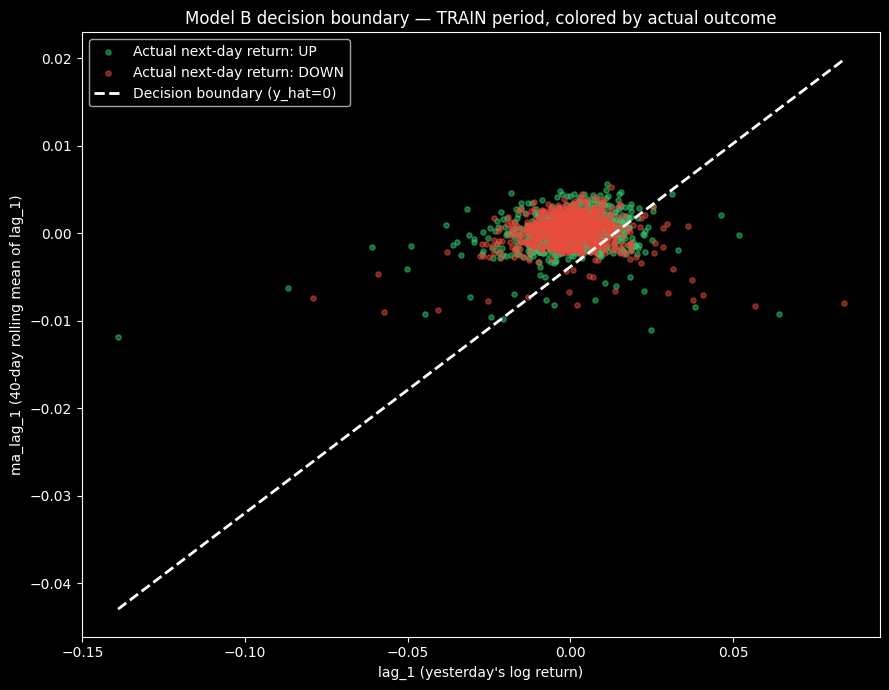

In [11]:
x1_range_train = np.linspace(train_b['close_log_return_lag_1'].min(), train_b['close_log_return_lag_1'].max(), 100)
boundary_x2_train = -(w1 * x1_range_train + b) / w2

up_train = train_b[train_b['close_log_return'] > 0]
down_train = train_b[train_b['close_log_return'] <= 0]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(up_train['close_log_return_lag_1'], up_train['close_log_return_ma_lag_1'],
           color='#2ecc71', s=14, alpha=0.5, label='Actual next-day return: UP')
ax.scatter(down_train['close_log_return_lag_1'], down_train['close_log_return_ma_lag_1'],
           color='#e74c3c', s=14, alpha=0.5, label='Actual next-day return: DOWN')
ax.plot(x1_range_train, boundary_x2_train, color='white', linewidth=2, linestyle='--', label='Decision boundary (y_hat=0)')
ax.set_xlabel('lag_1 (yesterday\'s log return)')
ax.set_ylabel('ma_lag_1 (40-day rolling mean of lag_1)')
ax.set_title('Model B decision boundary — TRAIN period, colored by actual outcome')
ax.legend()
plt.tight_layout()
plt.show()

### Sweep the shift constant `c` — using Train data ONLY

New rule: `signal = +1 if y_hat > c else -1`. Sweep `c` from a large negative
value (nearly everything becomes Sell) to a large positive value (nearly
everything becomes Buy), and for each `c` compute Train hit rate and the
resulting Buy/Sell split. Pick the `c` that looks best — by whatever
criterion (max hit rate, or a target Buy/Sell balance) — using this Train
sweep alone. That fixed `c` gets applied to Test in the next cell, unchanged.

Best c by Train hit rate:
c                   -0.000383
n_buy             1966.000000
n_sell              29.000000
train_hit_rate       0.536842
Name: 16, dtype: float64

        c  n_buy  n_sell  train_hit_rate
-0.002513   1994       1        0.535840
-0.001981   1993       2        0.535338
-0.001448   1992       3        0.535840
-0.000916   1985      10        0.536341
-0.000383   1966      29        0.536842
 0.000149   1659     336        0.506266
 0.000682    174    1821        0.465664
 0.001214     10    1985        0.466667
 0.001747      3    1992        0.465163
 0.002279      1    1994        0.464160
 0.002812      0    1995        0.463659


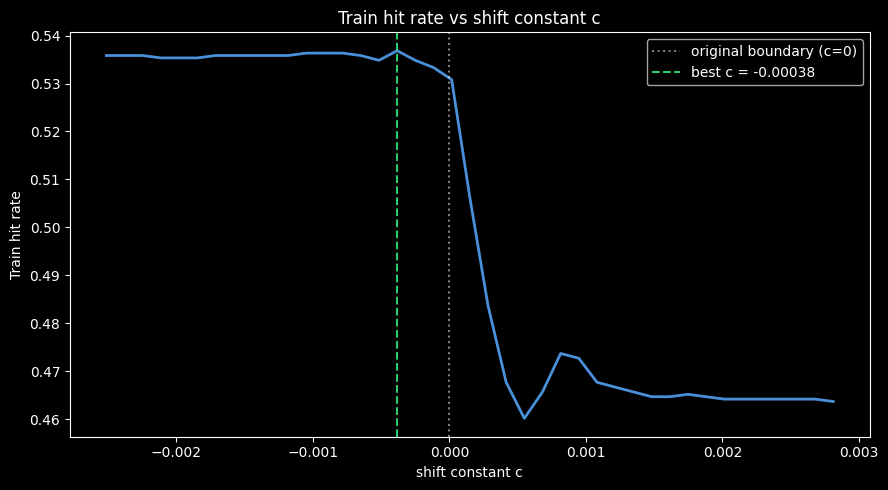

In [12]:
c_range = np.linspace(train_b['y_hat'].min(), train_b['y_hat'].max(), 41)

rows = []
for c in c_range:
    sig = np.where(train_b['y_hat'] > c, 1, -1)
    n_buy = (sig == 1).sum()
    n_sell = (sig == -1).sum()
    hit = (np.sign(train_b['close_log_return']) == sig).mean()
    rows.append({'c': c, 'n_buy': n_buy, 'n_sell': n_sell, 'train_hit_rate': hit})

sweep = pd.DataFrame(rows)
best_row = sweep.loc[sweep['train_hit_rate'].idxmax()]
print('Best c by Train hit rate:')
print(best_row)
print()
print(sweep.iloc[::4].to_string(index=False))  # every 4th row, so the whole range is visible without dumping all 41

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep['c'], sweep['train_hit_rate'], color='#4a90d9', linewidth=2)
ax.axvline(0, color='white', linestyle=':', alpha=0.5, label='original boundary (c=0)')
ax.axvline(best_row['c'], color='#2ecc71', linestyle='--', label=f"best c = {best_row['c']:.5f}")
ax.set_xlabel('shift constant c')
ax.set_ylabel('Train hit rate')
ax.set_title('Train hit rate vs shift constant c')
ax.legend()
plt.tight_layout()
plt.show()

### Apply that fixed `c` to Test — unchanged, no peeking

In [13]:
c_fixed = best_row['c']  # chosen from Train sweep above, applied as-is

test_shifted = test_b.copy()
test_shifted['signal_shifted'] = np.where(test_shifted['y_hat'] > c_fixed, 1, -1)
test_shifted['trade_log_return_shifted'] = test_shifted['close_log_return'] * test_shifted['signal_shifted']
test_shifted['cum_shifted'] = test_shifted['trade_log_return_shifted'].cumsum()

n_buy_test = (test_shifted['signal_shifted'] == 1).sum()
n_sell_test = (test_shifted['signal_shifted'] == -1).sum()
hit_rate_test = (np.sign(test_shifted['close_log_return']) == test_shifted['signal_shifted']).mean()

print(f'c_fixed (from Train) = {c_fixed:.6f}')
print(f'Test Buy days = {n_buy_test}   Test Sell days = {n_sell_test}')
print(f'Test hit rate (shifted rule) = {hit_rate_test:.4f}')
print(f'Test hit rate (original rule, c=0) = {(np.sign(test_b["close_log_return"]) == test_b["signal"]).mean():.4f}')
print()
print(f'Final cum (shifted rule): {test_shifted["cum_shifted"].iloc[-1]:.6f}')
print(f'Final cum (original rule): {test_b["cum_trade_log_return"].iloc[-1]:.6f}')
print(f'Final cum (Buy-and-hold): {buy_hold_b["cum_buy_hold"].iloc[-1]:.6f}')

c_fixed (from Train) = -0.000383
Test Buy days = 663   Test Sell days = 3
Test hit rate (shifted rule) = 0.5465
Test hit rate (original rule, c=0) = 0.5450

Final cum (shifted rule): 0.455828
Final cum (original rule): 0.379493
Final cum (Buy-and-hold): 0.377428


### The winning shifted line, plotted on Train (where it was chosen)

Same Train scatter as before, but now with BOTH lines: the original boundary
(`c=0`, dashed) and the new shifted boundary (`c=c_fixed`, solid green) that
the sweep found. Since `c_fixed` only changes the additive constant, this is
a parallel shift of the same line — same slope, moved down-and-right.

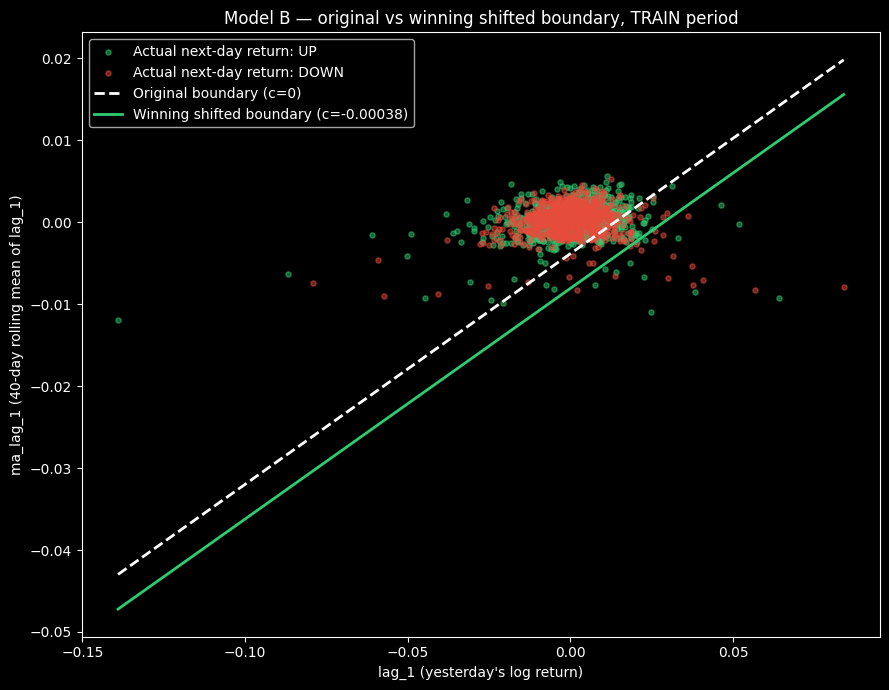

In [14]:
# winning shifted boundary: w1*x1 + w2*x2 + b = c_fixed  ->  x2 = (c_fixed - w1*x1 - b) / w2
boundary_x2_shifted_train = (c_fixed - w1 * x1_range_train - b) / w2

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(up_train['close_log_return_lag_1'], up_train['close_log_return_ma_lag_1'],
           color='#2ecc71', s=14, alpha=0.5, label='Actual next-day return: UP')
ax.scatter(down_train['close_log_return_lag_1'], down_train['close_log_return_ma_lag_1'],
           color='#e74c3c', s=14, alpha=0.5, label='Actual next-day return: DOWN')
ax.plot(x1_range_train, boundary_x2_train, color='white', linewidth=2, linestyle='--',
        label='Original boundary (c=0)')
ax.plot(x1_range_train, boundary_x2_shifted_train, color='#2ecc71', linewidth=2,
        label=f'Winning shifted boundary (c={c_fixed:.5f})')
ax.set_xlabel('lag_1 (yesterday\'s log return)')
ax.set_ylabel('ma_lag_1 (40-day rolling mean of lag_1)')
ax.set_title('Model B — original vs winning shifted boundary, TRAIN period')
ax.legend()
plt.tight_layout()
plt.show()

## Summary table — Train vs Test cum_trade_log_return, all 3 models

In [15]:
summary = pd.DataFrame({
    'model': ['Model A', 'MA-alone', 'Model B'],
    'train_n': [len(train_a), len(train_ma), len(train_b)],
    'train_cum': [train_a['cum_trade_log_return'].iloc[-1], train_ma['cum_trade_log_return'].iloc[-1], train_b['cum_trade_log_return'].iloc[-1]],
    'test_n': [len(test_a), len(test_ma), len(test_b)],
    'test_cum': [test_a['cum_trade_log_return'].iloc[-1], test_ma['cum_trade_log_return'].iloc[-1], test_b['cum_trade_log_return'].iloc[-1]],
})
summary

,model,train_n,train_cum,test_n,test_cum
0,Model A,2025,0.642982,675,0.437321
1,MA-alone,1995,0.743168,666,0.377428
2,Model B,1995,0.945299,666,0.379493
